In [1]:
%%html

<h1>Initializing Environment</h1>

In [43]:
%%capture 

import pandas as pd
import numpy as np
from transformers import RobertaModel, RobertaTokenizer
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import os
from itertools import cycle
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Original Dataset
# df = pd.read_csv("allsides-balanced.csv")

model = RobertaModel.from_pretrained("roberta-base")
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Enable M1 GPU, else rely on CPU
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [5]:
%%html

<h1>Cleaning & Understanding Data</h1>

<ul>
    <li>Removing index column</li>
    <li>Checking shape after each transformation</li>
    <li>Removing null and duplicate values</li>
    <li>Reset indices due to deleted rows</li>
</ul>

In [45]:
"""

Original Dataset
-No longer using this

"""
# df = df.drop(columns=df.columns[0])


# print(f"Initial Data Shape: {df.shape}\n\nData Types: \n{df.dtypes}\n")
# print(f"NA Values:\n{df.isna().sum()}\n\nNull Values:\n{df.isnull().sum()}\n\n")


# df = df.dropna(subset=["source", "text"])
# print(f"After Removing NA: {df.shape}\n")


# df = df.drop_duplicates(subset=["text"])
# print(f"After Removing Duplicate Articles: {df.shape}\n")


# df = df.reset_index(drop=True)

# df["article_id"] = df.index

Initial Data Shape: (21754, 6)

Data Types: 
title          str
tags           str
heading        str
source         str
text           str
bias_rating    str
dtype: object

NA Values:
title          0
tags           0
heading        0
source         8
text           7
bias_rating    0
dtype: int64

Null Values:
title          0
tags           0
heading        0
source         8
text           7
bias_rating    0
dtype: int64


After Removing NA: (21739, 6)

After Removing Duplicate Articles: (21715, 6)



In [63]:
def load_split(data_dir, split_type="random", split_name="train", use_processed=True):
    """
    data_dir: path to your data folder
    split_type: "random" or "media"
    split_name: "train", "val", or "test"
    use_processed: True -> use 'content', False -> use 'content_original'
    """

    # Paths
    json_dir = os.path.join(data_dir, "jsons")
    split_file = os.path.join(data_dir, "splits", split_type, f"{split_name}.tsv")

    # Load split file
    df = pd.read_csv(split_file, sep="\t")

    texts = []
    labels = []

    for _, row in df.iterrows():
        article_id = row["ID"]
        label = row["bias"]  # numeric label (0,1,2)

        json_path = os.path.join(json_dir, f"{article_id}.json")

        if not os.path.exists(json_path):
            continue  # skip missing files

        with open(json_path, "r", encoding="utf-8") as f:
            article = json.load(f)

        text = article["content"] if use_processed else article["content_original"]

        texts.append(text)
        labels.append(label)

    return texts, labels

In [69]:
data_dir = "ab-main/data"

X_train, y_train = load_split(data_dir, "media", "train")
X_val, y_val = load_split(data_dir, "media", "valid")
X_test, y_test = load_split(data_dir, "media", "test")

In [269]:
%%html

<h1>Feature Extraction Pipeline (roBERTa)</h1>

<p>
Data extraction pipeline to tokenize and convert article features into 768d float embeddings using batch processing of 32 articles at a time.
Mean-pooling utilized to calculate a culumative representational embedding for each article
</p>

In [73]:
def feature_extraction(texts, batch_size = 32):

    features = []
    
    # Utilizing GPU for data processing (M1)
    model.to(device)
    model.eval()

    for i in range(0, len(texts), batch_size):
    
        batch = texts[i : i + batch_size]
    
        input_articles = tokenizer(
            batch,
            padding = True,
            truncation = True,
            max_length = 512,
            return_tensors = "pt"
        )
    
        # Convert tensor outputs (CPU -> GPU)
        input_articles = { k: v.to(device) for k, v in input_articles.items() }
    
        with torch.no_grad():
            output_articles = model(**input_articles)

            # --- Mean-Attention Pooling---
    
            # Increase dimension of attention_mask to output_articles for to enable multiplication
            attention_mask = input_articles["attention_mask"].unsqueeze(-1)
    

            # Masked embeddings multiplication will zero out padding tokens 
            masked_embeddings = output_articles.last_hidden_state * attention_mask
       
    
            # Sum real tokens embedding, and divide by number of tokens per article
            token_counts = attention_mask.sum(1).clamp(min=1e-10)
            mean_batch = masked_embeddings.sum(1) / token_counts
            

            # Append features
            features.append(mean_batch.cpu())    


            # --- CLS Extraction ---

            # cls_batch = output_articles.last_hidden_state[:, 0, :]

            # features.append(cls_batch.cpu())

    return torch.cat(features, dim=0)

In [75]:
train_features = feature_extraction(X_train)
val_features = feature_extraction(X_val)
test_features = feature_extraction(X_test)

In [8]:
%%html

<h1>Defining Data Splits</h1>

<h3>What are our data-splits we are testing on?</h3>

<p>
Forming various data splits to test DANN on with roBERTa positional embeddings. We are testing various splits due to a key limitation identified
in the IQBias all-sides-balanced.csv dataset, that only has one political leaning per source outlet. For example, Fox News only contains articles
that have the right-leaning bias label, without containing article information that maps to left or center leaning.
</p>

<p>

<h5>(1) Grouping articles by triplets (common title maps -> (left, center, right) article)</h5>
    
<ul>
    <li>Group triplets, remove non-triplets</li>
    <li>Source is considered the article "title"</li>
</ul>
 
<h5>(2) Group outlets by outlet source (at training time) and testing on unseen outlets (at test time)</h5>

<ul>
    <li>May include class imbalance between (left, center, right) articles</li>
    <li>May not generalize during testing since each outlet has a distinct writing style during training</li>
</ul>
           
<h5>(3) Separate domain as source non-Fox outlet, and target Fox outlet articles</h5>

<ul>
    <li>May be limited since Fox news only contains right leaning articles</li>
    <li>May cause leakage, improper generalization</li>
</ul>

</p>

In [61]:
# -------- Split (1) --------

df_triplet = df.copy()

df_triplet["title"] = df_triplet["title"].str.strip().str.lower()

is_triplet = df_triplet.groupby("title")["bias_rating"].apply(
    lambda x: sorted(x.tolist()) == ["center", "left", "right"]
)

df_triplet = df_triplet[df_triplet["title"].isin(is_triplet[is_triplet].index)]

print(f"Triplet Bias Distribution:\n\n{df_triplet["bias_rating"].value_counts()}\n\nTotal Sources:\n\n{len(df_triplet)}")


# -------- Split (2) --------


df_unseen = df.copy()
print(df_unseen.columns)

print(f"Unseen Seen Bias Distribution:\n\n{df_unseen["bias_rating"].value_counts()}\n\nTotal Sources:\n\n{len(df_unseen)}")


seen = [
    # Left-leaning
    "CNN (Online News)", "Washington Post", "HuffPost", "NPR (Online News)", "Associated Press",
    "Vox", "The Guardian", "ABC News (Online)", "Bloomberg",
    
    # Center
    "The Hill", "Reuters", "Axios", "CNBC",  "Newsweek", "Christian Science Monitor",
    
    # Right-leaning
    "Washington Times", "Washington Examiner", "National Review", "The Blaze", "Breitbart News", 
    "CBN", "The Epoch Times", "Reason",
]

unseen = [
    # Left-leaning
    "New York Times (News)", "Politico", "NBC News (Online)",
    
    # Center
    "Wall Street Journal (News)", "BBC News",
    
    # Right-leaning
    "Fox News (Online News)", "Townhall", "Newsmax (News)",
]

print("\n\n")
print(df[df["source"].isin(unseen)]["bias_rating"].value_counts())
print(df[df["source"].isin(seen)]["bias_rating"].value_counts())

# -------- Split (3) --------

df_fox = df.copy()

fox_outlets = ["Fox News (Online News)", "Fox Business", "Fox News (Opinion)", "Fox News Latino"]

Triplet Bias Distribution:

bias_rating
left      3965
center    3965
right     3965
Name: count, dtype: int64

Total Sources:

11895
Index(['title', 'tags', 'heading', 'source', 'text', 'bias_rating',
       'article_id'],
      dtype='str')
Unseen Seen Bias Distribution:

bias_rating
left      10260
right      7214
center     4241
Name: count, dtype: int64

Total Sources:

21715



bias_rating
right     2825
left      2293
center    1203
Name: count, dtype: int64
bias_rating
left      5511
right     2860
center    2301
Name: count, dtype: int64


In [359]:
def save_split(split_type, to_dir):

    bias_rating_map = {"left" : 0, "center": 1, "right": 2}
    
    match split_type:

        case "triplet":

            triplet_features = article_features[df_triplet.index].cpu()
            triplet_labels = torch.tensor(df_triplet["bias_rating"].map(bias_rating_map).tolist())

            # Randomize order of titles
            unique_titles = np.random.permutation(df_triplet["title"].unique())

            # Create masks
            source_mask = torch.tensor([t in set(unique_titles[:int(0.8 * len(unique_titles))]) for t in df_triplet["title"].tolist()])
            target_mask = ~source_mask
            
            # Split embeddings
            train_embedding, train_labels = triplet_features[source_mask].cpu(), triplet_labels[source_mask]
            target_embedding, target_labels = triplet_features[target_mask].cpu(), triplet_labels[target_mask]


        case "unseen":

            unseen_labels = torch.tensor(df_unseen["bias_rating"].map(bias_rating_map).tolist())

             # Create masks
            source_mask = torch.tensor([s in seen for s in df_unseen["source"].tolist()])
            target_mask = torch.tensor([s in unseen for s in df_unseen["source"].tolist()])

            source_ids = df_unseen[source_mask.numpy().astype(bool)]["article_id"].values
            target_ids = df_unseen[target_mask.numpy().astype(bool)]["article_id"].values

            df_source = df_unseen[source_mask.numpy().astype(bool)]
            df_target = df_unseen[target_mask.numpy().astype(bool)]

            print(df_source["bias_rating"].value_counts())
            print(df_target["bias_rating"].value_counts())

            # Split embeddings
            train_embedding, train_labels = article_features[source_mask].cpu(), unseen_labels[source_mask]
            target_embedding, target_labels = article_features[target_mask].cpu(), unseen_labels[target_mask]
            
        case "fox":
            
            fox_labels  = torch.tensor(df_fox["bias_rating"].map(bias_rating_map).tolist())
            
            # Create masks
            source_mask = torch.tensor([s not in fox_outlets for s in df_fox["source"].tolist()])
            target_mask = ~source_mask

            # Split embeddings
            train_embedding, train_labels = article_features[source_mask].cpu(), fox_labels[source_mask]
            target_embedding, target_labels = article_features[target_mask].cpu(), fox_labels[target_mask]

    if os.path.isdir(to_dir): print(f"{to_dir} directory already exists!") 
    
    else:
        os.mkdir(to_dir)

        torch.save(train_embedding, f"{to_dir}/train_embedding.pt")
        torch.save(train_labels, f"{to_dir}/train_labels.pt")
        torch.save(target_embedding, f"{to_dir}/test_embedding.pt")
        torch.save(target_labels, f"{to_dir}/test_labels.pt")


save_split("triplet", "triplet_dir")
save_split("unseen", "unseen_dir")
save_split("fox", "fox_dir")

np.save(f"{to_dir}/train_ids.npy", source_ids)
np.save(f"{to_dir}/test_ids.npy", target_ids)

In [81]:
def tsv_dann_split(name, embedding, labels, to_dir):
    
    os.makedirs(to_dir, exist_ok=True)

    torch.save(embedding, f"{to_dir}/{name}_embedding.pt")
    torch.save(torch.tensor(labels), f"{to_dir}/{name}_labels.pt")

tsv_dann_split("train", train_features, y_train, "dann")
tsv_dann_split("val", val_features, y_val, "dann")
tsv_dann_split("test", test_features, y_test, "dann")

In [85]:
def weighted_sampler(labels):

    labels = labels.long().cpu()

    class_counts = torch.bincount(labels)
    sample_weights = 1.0 / class_counts[labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

def load_split(from_dir):

    train_embedding = torch.load(f"{from_dir}/train_embedding.pt").float()
    train_labels = torch.load(f"{from_dir}/train_labels.pt").long()

    val_embedding = torch.load(f"{from_dir}/val_embedding.pt").float()
    val_labels = torch.load(f"{from_dir}/val_labels.pt").long()
    
    test_embedding = torch.load(f"{from_dir}/test_embedding.pt").float()
    test_labels = torch.load(f"{from_dir}/test_labels.pt").long()
    
    # Source train (labels for Gy, Gd)
    source_loader = DataLoader(
        TensorDataset(train_embedding, train_labels),
        batch_size=32, 
        sampler=weighted_sampler(train_labels)
    )
    
    # Target train (no labels, Gd only)
    target_loader = DataLoader(
        TensorDataset(test_embedding),
        batch_size=32, 
        shuffle=True
    )

    return source_loader, target_loader, val_embedding, val_labels, test_embedding, test_labels

In [242]:
%%html

<h1>DANN Implementation</h1>

<h3>
Below is a quick reference table to the different components of the Domain Adversarial Neural Network implementation adapted from
Ganin et al. (<a href="https://arxiv.org/abs/1505.07818">Academic Paper</a>)
</h3>


<h5>(1) Gradient Reversal Layer</h5>
<h5>(2) Feature Extractor</h5>
<h5>(3) Adversarial Classifier</h5>
<h5>(4) Label Classifier</h5>
<h5>(5) DANN</h5>

In [9]:
# -------- (1) --------

class ReversalFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, lam):

        ctx.lam = lam
        
        return x.clone()

    @staticmethod
    def backward(ctx, gradient):

        return -ctx.lam * gradient, None

class GradientReversalLayer(nn.Module):

    def __init__(self):

        super().__init__()
        self.lam = 0.0

    def forward(self, x):
        return ReversalFunction.apply(x, self.lam)


# -------- (2) --------

class FeatureExtractor(nn.Module):

    def __init__(self):
        super().__init__()

        # Simple Feed-forward Network (Compress embeddings into domain-invariant features)
        self.network = nn.Sequential(
 
            nn.Linear(768, 512), # Reduce roBERTa embedding from 768 -> 256 representation
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256), # Reduce roBERTa embedding from 256 -> 128 representation
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
        
        )

    def forward(self, x):
        return self.network(x)


# -------- (3) --------

class AdversarialClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.grl = GradientReversalLayer()
        self.network = nn.Sequential(
            
            nn.Linear(256, 128), # Compressing 256 representation to 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64), # Compressing 128 representation to 64
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1) # Compressing 64 representation to 1 binary output
        )

    def forward(self, input_features):
        return self.network(self.grl(input_features))


# -------- (4) --------

class LabelClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(256, 128), # Compressing 256 representation to 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64), # Compressing 128 representation to 64
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3) # Compressing 128 representation to 3 output(s) (Left, Center, Right)
        )
        

    def forward(self, input_features):
        return self.network(input_features)


# -------- (5) --------

class DANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = FeatureExtractor()
        self.label_classifier = LabelClassifier()
        self.adversarial_classifier = AdversarialClassifier()

    def forward(self, x):

        features = self.feature_extractor(x)

        return self.label_classifier(features), self.adversarial_classifier(features)

In [363]:
%%html

<h1>Testing & Results</h1>

In [174]:
def train(from_dir, epochs=100, lr=1e-3, y=2, no_grl=True):
    
    source_loader, target_loader, val_embedding, val_labels, test_embedding, test_labels = load_split(from_dir)

    model = DANN().to(device)
    
    optimizer = torch.optim.Adam([
        {"params": model.feature_extractor.parameters(), "lr": lr},
        {"params": model.label_classifier.parameters(), "lr": lr},
        {"params": model.adversarial_classifier.parameters(), "lr": lr} 
    ])

    # Label Classification (Left, Right, Center)
    label_loss = nn.CrossEntropyLoss()

    # Domain Classifier (Source, Target)
    adversarial_loss = nn.BCEWithLogitsLoss()
    
    # Track steps
    steps = epochs * len(source_loader)
    current_step = 0
    
    for epoch in range(epochs):
        
        model.train()

        # Prevent target loader exhaustion
        target = cycle(target_loader)
        
        epoch_label_loss, epoch_domain_loss = 0.0, 0.0
        
        for (source_x, source_y) in source_loader:
            
            # Lambda Scheduling (lambda bounded from -> (0,1))
            p = current_step / steps
            lam = 2 / (1 + np.exp(-y * p)) - 1

            source_x = source_x.to(device)
            source_y = source_y.to(device)

            # On foward pass, generate source and domain prediction 
            source_label_pred, source_domain_pred = model(source_x)

            # Compute source loss
            loss_label = label_loss(source_label_pred, source_y)

            # Without DANN
            if no_grl:
                model.adversarial_classifier.grl.lam = 0
                loss = loss_label
                loss_domain = torch.tensor(0.0, device=device)

            # With DANN
            else:
                
                model.adversarial_classifier.grl.lam = lam
            
                # Unpack next target batch
                (target_x,) = next(target)
                target_x = target_x.to(device)
            
                # Domain labels (source, target)
                source_domain = torch.zeros(source_x.size(0), 1).to(device)
                target_domain = torch.ones(target_x.size(0), 1).to(device)
                
                _, target_domain_pred = model(target_x)
                
                # Calculate domain loss (source and target)
                loss_domain = adversarial_loss(source_domain_pred, source_domain) + adversarial_loss(target_domain_pred, target_domain)
                
                loss = loss_label + 0.5 * loss_domain
                
            # Back-propagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
  
            epoch_label_loss += loss_label.item()
            epoch_domain_loss += loss_domain.item()
            current_step += 1
        
        # Average label & domain loss
        avg_ll, avg_dl = epoch_label_loss / len(source_loader), epoch_domain_loss / len(source_loader)

        # Training summary (epoch, lamda, label & domain loss)
        print(f"[Epoch: {epoch+1}/{epochs} - Lambda: {lam:.5f} - Label Loss: {avg_ll:.5f} - Domain Loss: {avg_dl:.5f}]")
    
    return model, val_embedding, val_labels, test_embedding, test_labels

In [176]:
# Baseline - TSV Data

print("Baseline (No DANN)\n")
model_no_lam, val_embedding_no_lam, val_labels_no_lam, test_embedding_no_lam, test_labels_no_lam = train("dann", no_grl=True)
print("\n")

      
# DANN - TSV Data

print("DANN\n")
model_lam, val_embedding_lam, val_labels_lam, test_embedding_lam, test_labels_lam = train("dann", no_grl=False)
print("\n")

Baseline (No DANN)

[Epoch: 1/100 - Lambda: 0.00999 - Label Loss: 0.91896 - Domain Loss: 0.00000]
[Epoch: 2/100 - Lambda: 0.01999 - Label Loss: 0.74908 - Domain Loss: 0.00000]
[Epoch: 3/100 - Lambda: 0.02998 - Label Loss: 0.68762 - Domain Loss: 0.00000]
[Epoch: 4/100 - Lambda: 0.03997 - Label Loss: 0.64103 - Domain Loss: 0.00000]
[Epoch: 5/100 - Lambda: 0.04995 - Label Loss: 0.60549 - Domain Loss: 0.00000]
[Epoch: 6/100 - Lambda: 0.05992 - Label Loss: 0.58207 - Domain Loss: 0.00000]
[Epoch: 7/100 - Lambda: 0.06987 - Label Loss: 0.55294 - Domain Loss: 0.00000]
[Epoch: 8/100 - Lambda: 0.07982 - Label Loss: 0.54002 - Domain Loss: 0.00000]
[Epoch: 9/100 - Lambda: 0.08975 - Label Loss: 0.51541 - Domain Loss: 0.00000]
[Epoch: 10/100 - Lambda: 0.09966 - Label Loss: 0.49474 - Domain Loss: 0.00000]
[Epoch: 11/100 - Lambda: 0.10955 - Label Loss: 0.47064 - Domain Loss: 0.00000]
[Epoch: 12/100 - Lambda: 0.11942 - Label Loss: 0.46027 - Domain Loss: 0.00000]
[Epoch: 13/100 - Lambda: 0.12926 - Label 

In [177]:
def evaluate(model, embedding, labels, split_name, chart_name, save=False):

    model.eval()
    model.to(device)

    embedding = embedding.to(device)

    label_names = ["Left", "Center", "Right"]

    """
    Label Logits  -> Unnormalized Bias Scores
    Probabilities -> Normalize Probabilties [Lp, Cp, Rp] -> [0, 1], 
    Predictions   -> Select Highest Probability to Be Article Prediction
    """
    
    with torch.no_grad():
        
        label_logits, _ = model(embedding)        
        probabilities = torch.softmax(label_logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

    # Convert tensors to numpy arrays
    predictions_np  = predictions.cpu().numpy()
    probabilities_np = probabilities.cpu().numpy()
    labels_np = labels.cpu().numpy()

    accuracy = (predictions_np == labels_np).mean()
    
    print(f"{split_name}\n\nAccuracy: ({accuracy:.3f})\n")
    print(f"Classification Report:\n{classification_report(labels_np, predictions_np, target_names=label_names)}")

    # Confusion matrix
    conf_matrix = confusion_matrix(labels_np, predictions_np)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        conf_matrix,
        xticklabels=label_names,
        yticklabels=label_names,
        annot=True,
        fmt="d",
        cmap="PuRd",
        cbar=True
    )
    
    plt.title(f"{chart_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

    print('=' * 112)

    if save:
        np.save(f"{split_name}_probs.npy", probabilities_np)
        np.save(f"{split_name}_labels.npy", labels_np)

    # print(f"{predictions_np.shape}\n")
    # print(f"{probabilities_np.shape}\n")
    # print(f"{labels_np.shape}\n")

    return predictions_np, probabilities_np, labels_np



Accuracy: (0.283)

Classification Report:
              precision    recall  f1-score   support

        Left       0.65      0.23      0.34      1640
      Center       0.36      0.37      0.36       618
       Right       0.06      0.65      0.10        98

    accuracy                           0.28      2356
   macro avg       0.36      0.42      0.27      2356
weighted avg       0.55      0.28      0.33      2356



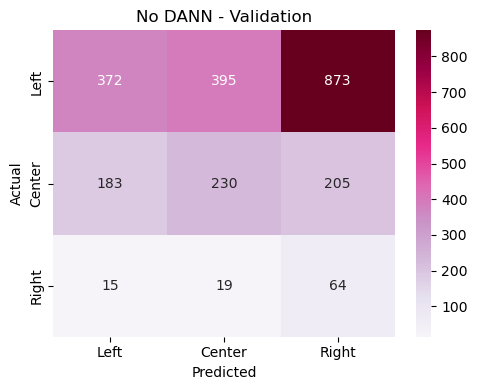



Accuracy: (0.460)

Classification Report:
              precision    recall  f1-score   support

        Left       0.44      0.27      0.34       402
      Center       0.24      0.24      0.24       299
       Right       0.56      0.69      0.62       599

    accuracy                           0.46      1300
   macro avg       0.41      0.40      0.40      1300
weighted avg       0.45      0.46      0.44      1300



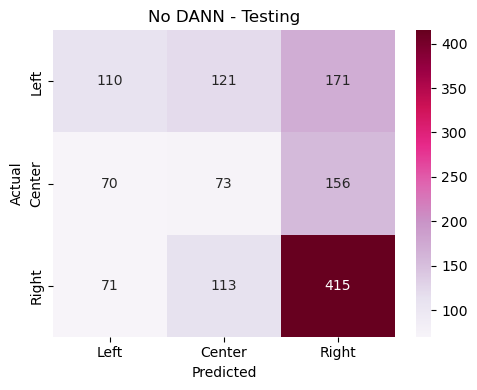

In [184]:
# No DANN - Validation
p1, p2, p3  = evaluate(
    model_no_lam, 
    val_embedding_no_lam, 
    val_labels_no_lam,
    "",
    "No DANN - Validation",
    save = False)

# No DANN - Test
_, _, _  = evaluate(
    model_no_lam, 
    test_embedding_no_lam, 
    test_labels_no_lam,
    "",
    "No DANN - Testing",
    save = False)

In [188]:
print(p)

[[3.0949285e-02 4.3099931e-06 9.6904647e-01]
 [1.0863386e-02 2.4307735e-01 7.4605924e-01]
 [2.8435844e-07 9.9959129e-01 4.0846699e-04]
 ...
 [6.0866187e-06 5.1371526e-04 9.9948019e-01]
 [1.6146972e-05 3.9666700e-03 9.9601716e-01]
 [2.4560285e-01 1.2666492e-03 7.5313061e-01]]


dann_val

Accuracy: (0.355)

Classification Report:
              precision    recall  f1-score   support

        Left       0.67      0.34      0.45      1640
      Center       0.39      0.38      0.38       618
       Right       0.06      0.52      0.10        98

    accuracy                           0.36      2356
   macro avg       0.37      0.41      0.31      2356
weighted avg       0.57      0.36      0.42      2356



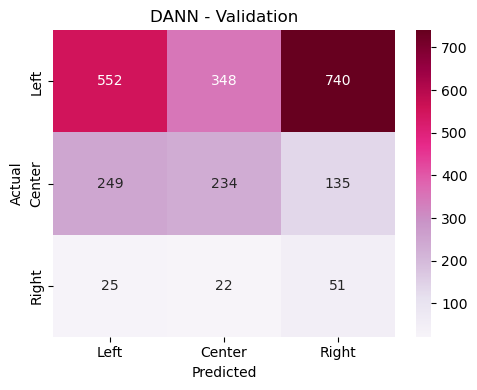

dann_test

Accuracy: (0.498)

Classification Report:
              precision    recall  f1-score   support

        Left       0.41      0.44      0.43       402
      Center       0.35      0.51      0.42       299
       Right       0.72      0.53      0.61       599

    accuracy                           0.50      1300
   macro avg       0.50      0.49      0.49      1300
weighted avg       0.54      0.50      0.51      1300



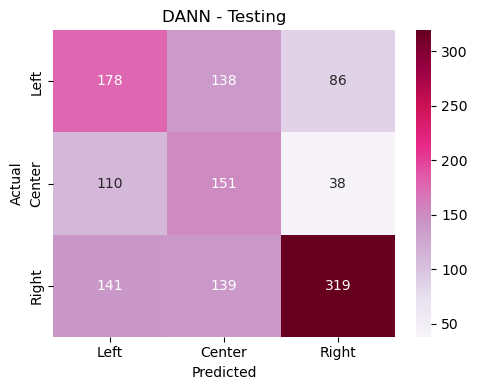

In [179]:
# DANN - Validation
_, _, _  = evaluate(
    model_lam, 
    val_embedding_lam, 
    val_labels_lam,
    "dann_val",
    "DANN - Validation",
    save = True)

# DANN - Test
_, _, _  = evaluate(
    model_lam, 
    test_embedding_lam, 
    test_labels_lam,
    "dann_test",
    "DANN - Testing",
    save = True)